In [7]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [23]:
#defining our State
class BMI_Test(TypedDict):
  height_m : float
  weight: float
  bmi: float
  category: str

In [24]:
#creating a node for processing
def calculate_bmi(state: BMI_Test)-> BMI_Test:
  height = state["height_m"]
  weight = state["weight"]

  state["bmi"] = round(weight / (height**2),2)

  return state


In [25]:
def category(state: BMI_Test)-> BMI_Test:
  bmi = state["bmi"]

  if bmi < 18.5:
    state["category"] = "Underweight"
  elif bmi >= 18.5 and bmi < 25:
    state["category"] = "Normal"
  elif bmi >= 25 and bmi < 30:
    state["category"] = "Overweight"
  else:
    state["category"] = "Obese"
  return state


In [26]:
#creating graph
graph = StateGraph(BMI_Test)

#creating nodes for processing
graph.add_node("calculate_bmi", calculate_bmi)
#adding another node
graph.add_node("category", category)
#creating an edge
graph.add_edge(START, "calculate_bmi")
#adding new edge
graph.add_edge("calculate_bmi", "category")
graph.add_edge("category", END)

#initializing the graph
workflow = graph.compile()

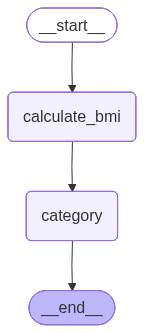

In [27]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [28]:
intial_state = {"height_m":1.73, "weight":80}
output_state = workflow.invoke(intial_state)
print(output_state)

{'height_m': 1.73, 'weight': 80, 'bmi': 26.73, 'category': 'Overweight'}
